1. Imports and setup

In [4]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot style
sns.set_theme(style="whitegrid")

2. Load the dataset

In [5]:
# Replace with your actual file path
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [6]:
# First look
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [7]:
# Structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [12]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [8]:
# Basic summary
df.describe(include="all")

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
count,2.443651e+06,2443651,2443651,2.443651e+06,2.443651e+06,2.443651e+06,2443651,2.443651e+06,2443651
unique,NaN,2222742,2077591,NaN,NaN,NaN,2,NaN,296
top,NaN,B0884G1PZ5,OYhmc Portable Pedal Exerc,NaN,NaN,NaN,False,NaN,Sports & Outdoors
freq,NaN,7,723,NaN,NaN,NaN,2435671,NaN,836265
mean,1.370545e+06,NaN,NaN,2.152836e+00,4.806278e+02,8.924381e+01,NaN,2.589699e+01,NaN
std,8.160562e+05,NaN,NaN,2.194865e+00,5.944124e+03,3.456089e+02,NaN,2.404837e+02,NaN
min,1.000000e+00,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,0.000000e+00,NaN
25%,6.589215e+05,NaN,NaN,0.000000e+00,0.000000e+00,9.990000e+00,NaN,0.000000e+00,NaN
50%,1.349029e+06,NaN,NaN,0.000000e+00,0.000000e+00,1.909000e+01,NaN,0.000000e+00,NaN
75%,2.060686e+06,NaN,NaN,4.400000e+00,5.900000e+01,4.599000e+01,NaN,0.000000e+00,NaN


3. Initial data cleaning

In [9]:
# Missing values
df.isna().sum().sort_values(ascending=False)

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [10]:
# Check duplicated rows
df.duplicated().sum()

np.int64(0)

In [13]:
# Convert price and stars to numeric if needed
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["stars"] = pd.to_numeric(df["stars"], errors="coerce")

In [14]:
# Optional: keep only rows with relevant values for this lab
df_clean = df.copy()

Part 1: Understanding Product Categories
Business Question
What are the most popular product categories on Amazon UK, and how do they compare in terms of listing frequency?


1. Frequency table for category

In [15]:
category_freq = df_clean["category"].value_counts(dropna=False)
category_freq

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Motorbike Chassis                            107
Alexa Built-In Devices                       107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

In [16]:
category_freq_table = df_clean["category"].value_counts(dropna=False).reset_index()
category_freq_table.columns = ["category", "frequency"]
category_freq_table["percentage"] = (
    category_freq_table["frequency"] / category_freq_table["frequency"].sum() * 100
)
category_freq_table.head(10)

,category,frequency,percentage
0,Sports & Outdoors,836265,34.221949
1,Beauty,19312,0.790293
2,"Handmade Clothing, Shoes & Accessories",19229,0.786896
3,Bath & Body,19092,0.781290
4,Birthday Gifts,18978,0.776625
5,Manicure & Pedicure Products,18940,0.775070
6,Skin Care,18769,0.768072
7,Make-up,18756,0.767540
8,Hair Care,18735,0.766681
9,Fragrances,18564,0.759683


Top 5 most listed product categories

In [17]:
top_5_categories = df_clean["category"].value_counts().head(5)
top_5_categories

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

2. Bar chart of product categories

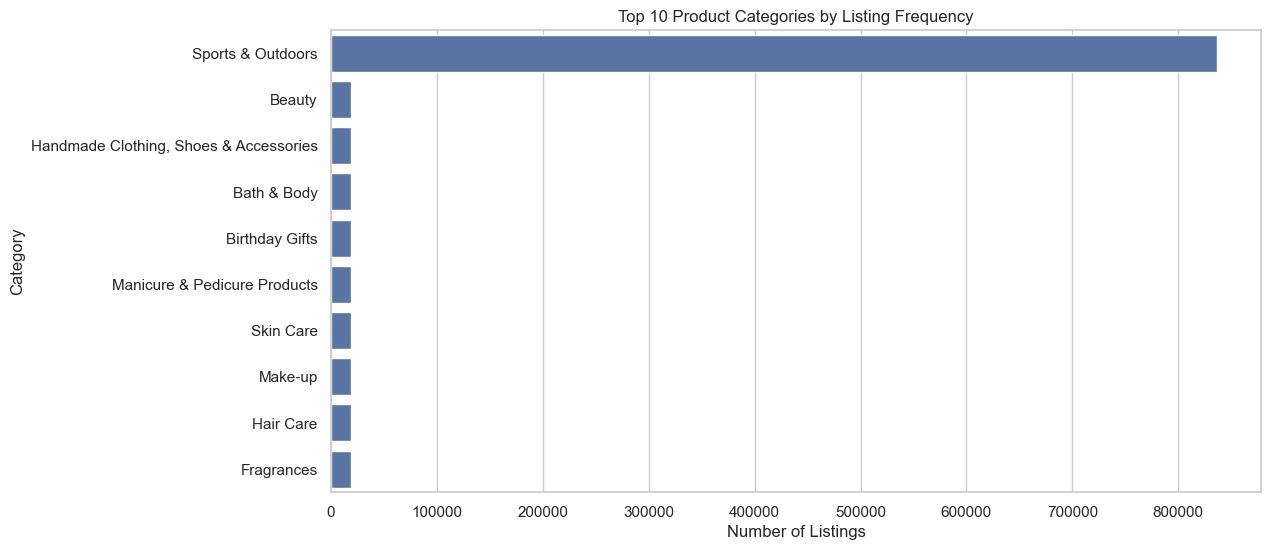

In [18]:
top_10_categories = df_clean["category"].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_categories.values, y=top_10_categories.index)
plt.title("Top 10 Product Categories by Listing Frequency")
plt.xlabel("Number of Listings")
plt.ylabel("Category")
plt.show()

3. Pie chart for top categories

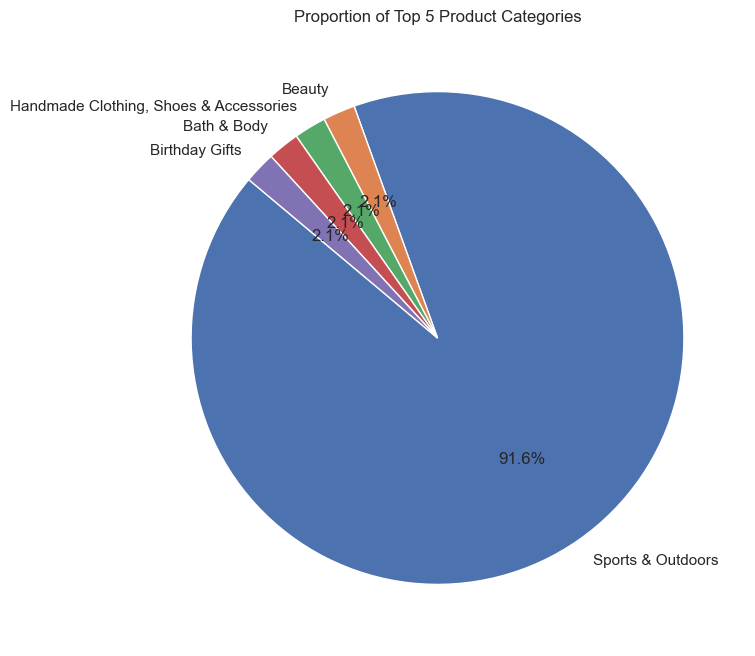

In [19]:
top_5_categories = df_clean["category"].value_counts().head(5)

plt.figure(figsize=(8, 8))
plt.pie(
    top_5_categories.values,
    labels=top_5_categories.index,
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Proportion of Top 5 Product Categories")
plt.show()

Business interpretation

In [20]:
top_5_categories / top_5_categories.sum() * 100

category
Sports & Outdoors                         91.607732
Beauty                                     2.115512
Handmade Clothing, Shoes & Accessories     2.106420
Bath & Body                                2.091412
Birthday Gifts                             2.078924
Name: count, dtype: float64

Part 2: Delving into Product Pricing
Business Question
How are products priced on Amazon UK, and are there specific price points or ranges that are more common?


1. Measures of centrality for price

In [21]:
price_data = df_clean["price"].dropna()

price_mean = price_data.mean()
price_median = price_data.median()
price_mode = price_data.mode()

print("Mean price:", price_mean)
print("Median price:", price_median)
print("Mode price:")
print(price_mode.head())

Mean price: 89.24380943923663
Median price: 19.09
Mode price:
0    9.99
Name: price, dtype: float64


2. Measures of dispersion for price

In [22]:
price_variance = price_data.var()
price_std = price_data.std()
price_range = price_data.max() - price_data.min()
price_iqr = price_data.quantile(0.75) - price_data.quantile(0.25)

print("Variance:", price_variance)
print("Standard Deviation:", price_std)
print("Range:", price_range)
print("Interquartile Range (IQR):", price_iqr)

Variance: 119445.48532254907
Standard Deviation: 345.60886175349884
Range: 100000.0
Interquartile Range (IQR): 36.0


3. Histogram of product prices

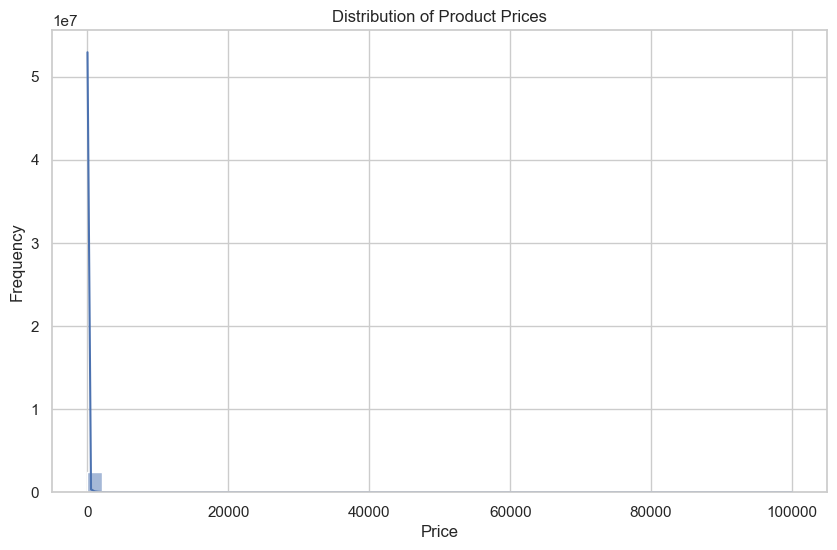

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(price_data, bins=50, kde=True)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Focus on the main bulk of the data

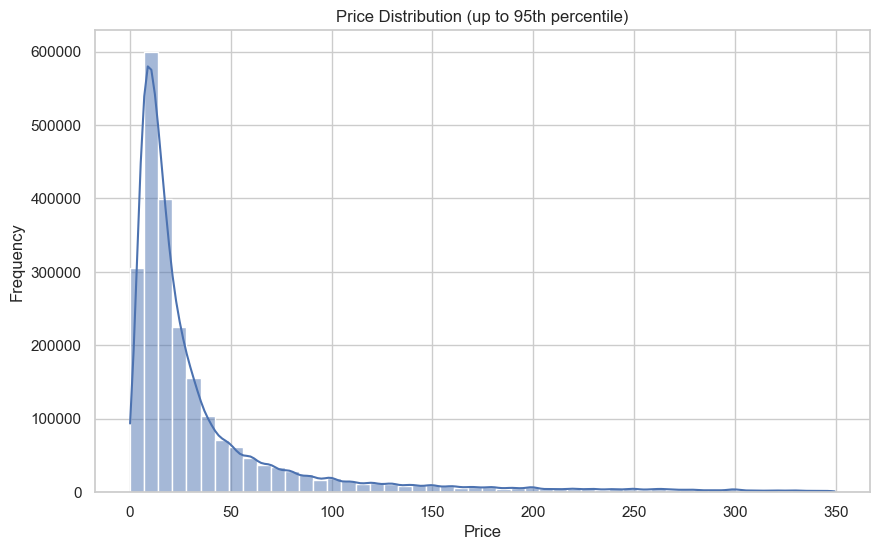

In [24]:
upper_limit = price_data.quantile(0.95)

plt.figure(figsize=(10, 6))
sns.histplot(price_data[price_data <= upper_limit], bins=50, kde=True)
plt.title("Price Distribution (up to 95th percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Log-transformed histogram

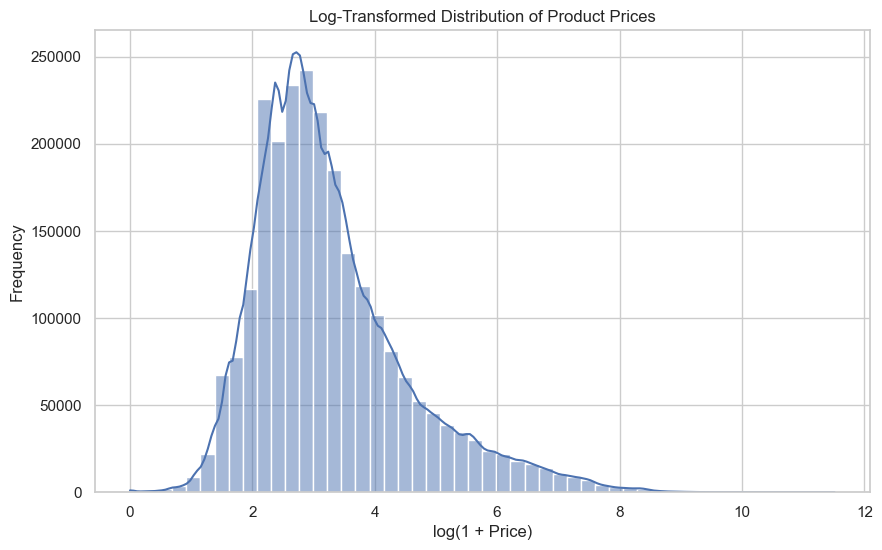

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(price_data), bins=50, kde=True)
plt.title("Log-Transformed Distribution of Product Prices")
plt.xlabel("log(1 + Price)")
plt.ylabel("Frequency")
plt.show()

4. Box plot for product prices

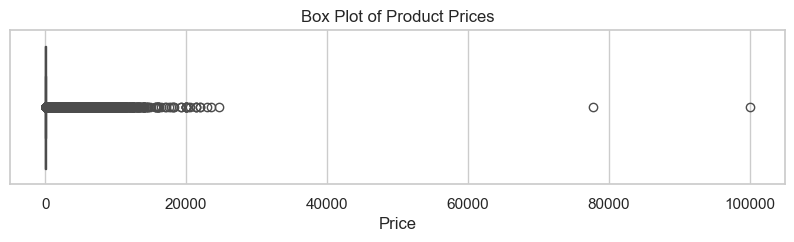

In [26]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=price_data)
plt.title("Box Plot of Product Prices")
plt.xlabel("Price")
plt.show()

Detecting outliers with IQR rule

In [27]:
Q1 = price_data.quantile(0.25)
Q3 = price_data.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = price_data[(price_data < lower_bound) | (price_data > upper_bound)]

print("Number of outliers:", outliers.shape[0])
print("Percentage of outliers:", outliers.shape[0] / price_data.shape[0] * 100)

Number of outliers: 327688
Percentage of outliers: 13.409770871536075


Part 3: Unpacking Product starss
Business Question
How do customers rate products on Amazon UK, and are there any patterns or tendencies in the starss?


1. Measures of centrality for stars

In [29]:
stars_data = df_clean["stars"].dropna()

stars_mean = stars_data.mean()
stars_median = stars_data.median()
stars_mode = stars_data.mode()

print("Mean stars:", stars_mean)
print("Median stars:", stars_median)
print("Mode stars:")
print(stars_mode.head())

Mean stars: 2.152836472966065
Median stars: 0.0
Mode stars:
0    0.0
Name: stars, dtype: float64


2. Measures of dispersion for stars

In [30]:
stars_variance = stars_data.var()
stars_std = stars_data.std()
stars_iqr = stars_data.quantile(0.75) - stars_data.quantile(0.25)

print("Variance:", stars_variance)
print("Standard Deviation:", stars_std)
print("IQR:", stars_iqr)

Variance: 4.817434029796862
Standard Deviation: 2.1948653785134207
IQR: 4.4


3. Shape of the distribution: skewness and kurtosis

In [31]:
stars_skewness = stars_data.skew()
stars_kurtosis = stars_data.kurt()

print("Skewness:", stars_skewness)
print("Kurtosis:", stars_kurtosis)

Skewness: 0.08120735761080985
Kurtosis: -1.9260061280432985


4. Histogram of product starss

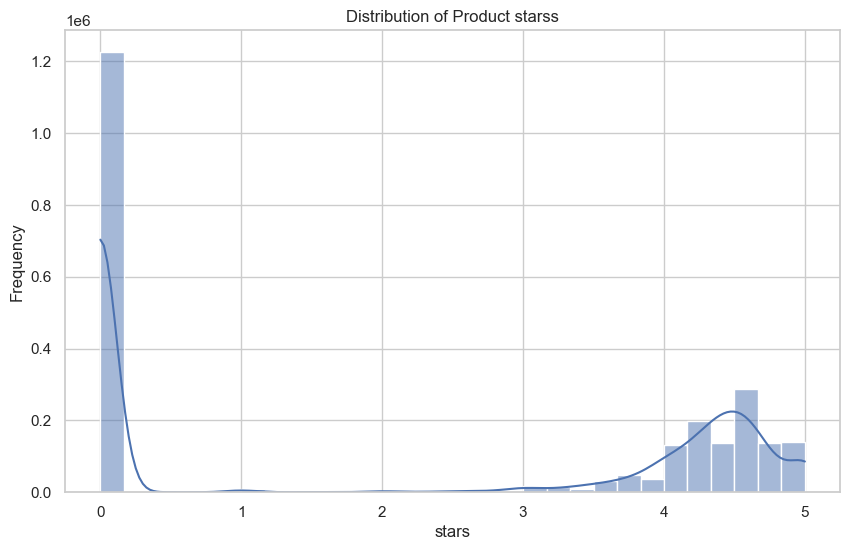

In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(stars_data, bins=30, kde=True)
plt.title("Distribution of Product starss")
plt.xlabel("stars")
plt.ylabel("Frequency")
plt.show()

inspect the exact most frequent values:

In [33]:
stars_data.value_counts().sort_index()

stars
0.0    1225641
1.0       8484
1.1          3
1.2         23
1.3         78
1.4        149
1.5        404
1.6        147
1.7        177
1.8        249
1.9        300
2.0       3901
2.1        540
2.2        602
2.3        734
2.4       1060
2.5       2103
2.6       1579
2.7       2104
2.8       2306
2.9       3341
3.0      12819
3.1       4679
3.2       5771
3.3       8269
3.4      10355
3.5      14673
3.6      16219
3.7      21137
3.8      27876
3.9      36555
4.0      66089
4.1      65115
4.2      86871
4.3     112564
4.4     136165
4.5     151577
4.6     136995
4.7      94566
4.8      41858
4.9      11081
5.0     128492
Name: count, dtype: int64

Final business-centric summary

In [34]:
print("Top 5 categories:")
display(top_5_categories)

print(f"Mean price: {price_mean:.2f}")
print(f"Median price: {price_median:.2f}")
print(f"Price std: {price_std:.2f}")
print(f"Price IQR: {price_iqr:.2f}")

print(f"Mean stars: {stars_mean:.2f}")
print(f"Median stars: {stars_median:.2f}")
print(f"stars std: {stars_std:.2f}")
print(f"stars skewness: {stars_skewness:.2f}")
print(f"stars kurtosis: {stars_kurtosis:.2f}")

Top 5 categories:


category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
Name: count, dtype: int64

Mean price: 89.24
Median price: 19.09
Price std: 345.61
Price IQR: 36.00
Mean stars: 2.15
Median stars: 0.00
stars std: 2.19
stars skewness: 0.08
stars kurtosis: -1.93
